<a href="https://colab.research.google.com/github/tennisvish/CancerGameTheory/blob/main/TumorGameTheory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

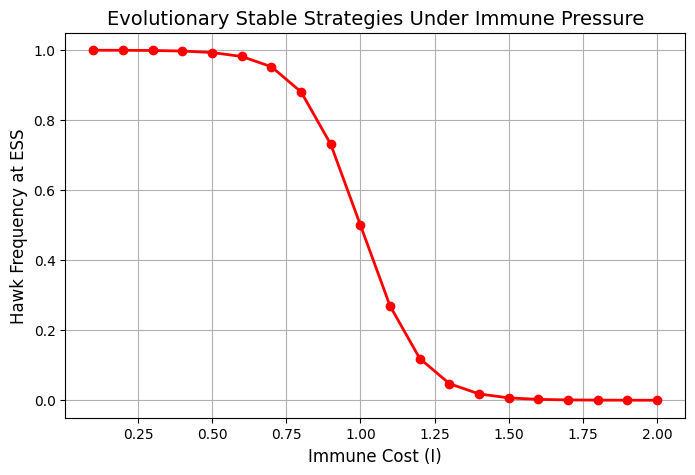

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters (modify these based on biological data)
b = 2.0   # Benefit of resource uptake (e.g., glucose)
c = 1.0   # Cost of competition (e.g., energy wasted on aggression)
I_range = np.linspace(0.1, 2.0, 20)  # Immune cost range (low to high pressure)

# Replicator equation
def replicator(xH, t, b, c, I):
    xD = 1 - xH
    fH = xH * (b - c - I) + xD * (b - I)  # Hawk fitness
    fD = xD * (b / 2)                      # Dove fitness
    phi = xH * fH + xD * fD                # Mean fitness
    return xH * (fH - phi)

# Simulate ESS for different immune pressures
results = []
for I in I_range:
    time = np.linspace(0, 10, 100)  # Simulation time
    xH_initial = 0.5                # Initial Hawk frequency (50%)
    xH = odeint(replicator, xH_initial, time, args=(b, c, I))[-1]  # Equilibrium
    results.append(xH[0])

# Plot ESS vs. Immune cost
plt.figure(figsize=(8, 5))
plt.plot(I_range, results, 'o-', color='red', linewidth=2)
plt.xlabel('Immune Cost (I)', fontsize=12)
plt.ylabel('Hawk Frequency at ESS', fontsize=12)
plt.title('Evolutionary Stable Strategies Under Immune Pressure', fontsize=14)
plt.grid(True)
plt.show()

In [13]:
#Pearson r test on the above plot

from scipy.stats import pearsonr

# Calculate Pearson r and p-value
correlation, p_value = pearsonr(I_range, results)

print(f"Pearson r correlation coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson r correlation coefficient: -0.9358
P-value: 0.0000


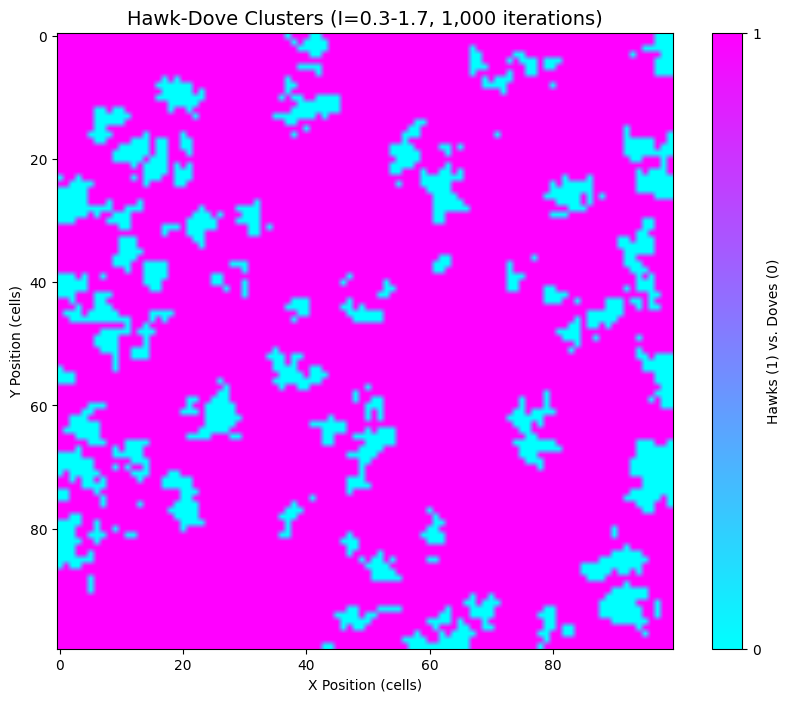

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 100  # Larger grid for better patterns
b, c = 2.0, 1.0  # Payoff parameters (b > c)
I_min, I_max = 0.3, 1.7  # Immune pressure range (clinical focus)
iterations = 1000  # More iterations for equilibrium

# Initialize grid and immune pressure
grid = np.random.choice(['H', 'D'], size=(n, n))
I_grid = np.random.uniform(I_min, I_max, size=(n, n))  # Spatially varying I

# Payoff calculation (Von Neumann neighborhood)
def calculate_payoff(grid, i, j, b, c, I):
    neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
    payoff = 0
    for ni, nj in neighbors:
        if 0 <= ni < n and 0 <= nj < n:
            if grid[i, j] == 'H':
                payoff += (b - c - I) if grid[ni, nj] == 'H' else (b - I)
            else:
                payoff += 0 if grid[ni, nj] == 'H' else (b / 2)
    return payoff

# Update rule (efficient neighbor selection)
def update_grid(grid, b, c, I_grid):
    new_grid = grid.copy()
    for i, j in np.ndindex(grid.shape):
        payoff = calculate_payoff(grid, i, j, b, c, I_grid[i, j])
        neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
        valid_neighbors = [(ni, nj) for ni, nj in neighbors if 0 <= ni < n and 0 <= nj < n]
        if valid_neighbors:
            ni, nj = valid_neighbors[np.random.randint(len(valid_neighbors))]
            neighbor_payoff = calculate_payoff(grid, ni, nj, b, c, I_grid[ni, nj])
            if neighbor_payoff > payoff:
                new_grid[i, j] = grid[ni, nj]
    return new_grid

# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Visualization
plt.figure(figsize=(10, 8))
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid],
           cmap='cool', interpolation='bilinear')  # Smoother edges
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1])
plt.title('Hawk-Dove Clusters (I=0.3-1.7, 1,000 iterations)', fontsize=14)
plt.xlabel('X Position (cells)' )  # units
plt.ylabel('Y Position (cells)')
plt.show()

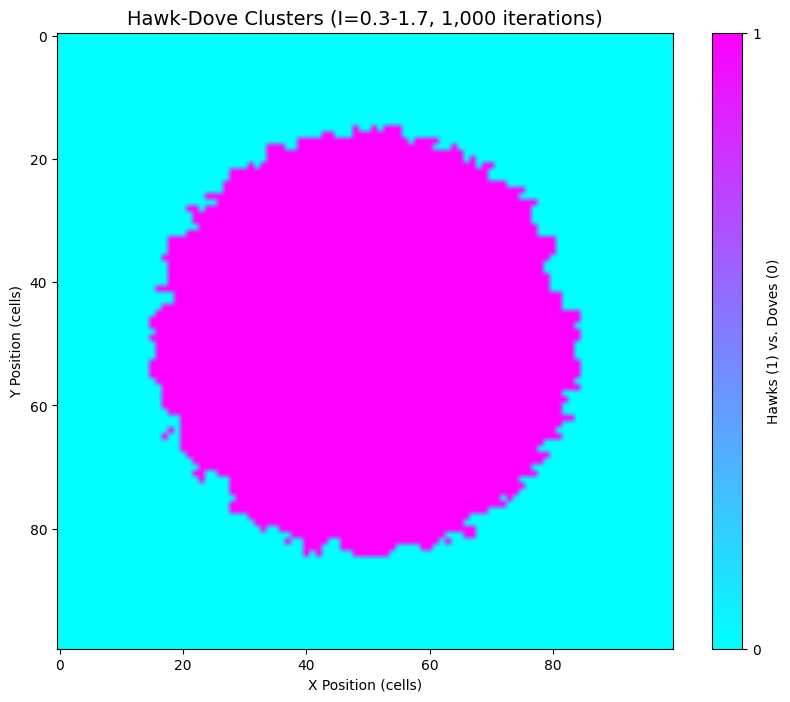

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 100  # Larger grid for better patterns
b, c = 2.0, 1.0  # Payoff parameters (b > c)
I_min, I_max = 0.3, 1.7  # Immune pressure range (clinical focus)
iterations = 1000  # More iterations for equilibrium

# Initialize grid and immune pressure
grid = np.random.choice(['H', 'D'], size=(n, n))
x, y = np.meshgrid(np.linspace(-1, 1, n), np.linspace(-1, 1, n))
I_grid = 0.5 + (1.0 * (x**2 + y**2))  # Center: I=0.5, Edges: I=1.5
I_grid = np.clip(I_grid, 0.5, 1.5)  # Ensure I stays in bounds

# Payoff calculation (Von Neumann neighborhood)
def calculate_payoff(grid, i, j, b, c, I):
    neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
    payoff = 0
    for ni, nj in neighbors:
        if 0 <= ni < n and 0 <= nj < n:
            if grid[i, j] == 'H':
                payoff += (b - c - I) if grid[ni, nj] == 'H' else (b - I)
            else:
                payoff += 0 if grid[ni, nj] == 'H' else (b / 2)
    return payoff

# Update rule (neighbor selection)
def update_grid(grid, b, c, I_grid):
    new_grid = grid.copy()
    for i, j in np.ndindex(grid.shape):
        payoff = calculate_payoff(grid, i, j, b, c, I_grid[i, j])
        neighbors = [(i-1, j), (i+1, j), (i, j-1), (i, j+1)]
        valid_neighbors = [(ni, nj) for ni, nj in neighbors if 0 <= ni < n and 0 <= nj < n]
        if valid_neighbors:
            ni, nj = valid_neighbors[np.random.randint(len(valid_neighbors))]
            neighbor_payoff = calculate_payoff(grid, ni, nj, b, c, I_grid[ni, nj])
            if neighbor_payoff > payoff:
                new_grid[i, j] = grid[ni, nj]
    return new_grid

# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Visualization
plt.figure(figsize=(10, 8))
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid],
           cmap='cool', interpolation='bilinear')  # Smoother edges
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1])
plt.title('Hawk-Dove Clusters (I=0.3-1.7, 1,000 iterations)', fontsize=14)
plt.xlabel('X Position (cells)' )  # units if possible
plt.ylabel('Y Position (cells)')
plt.show()

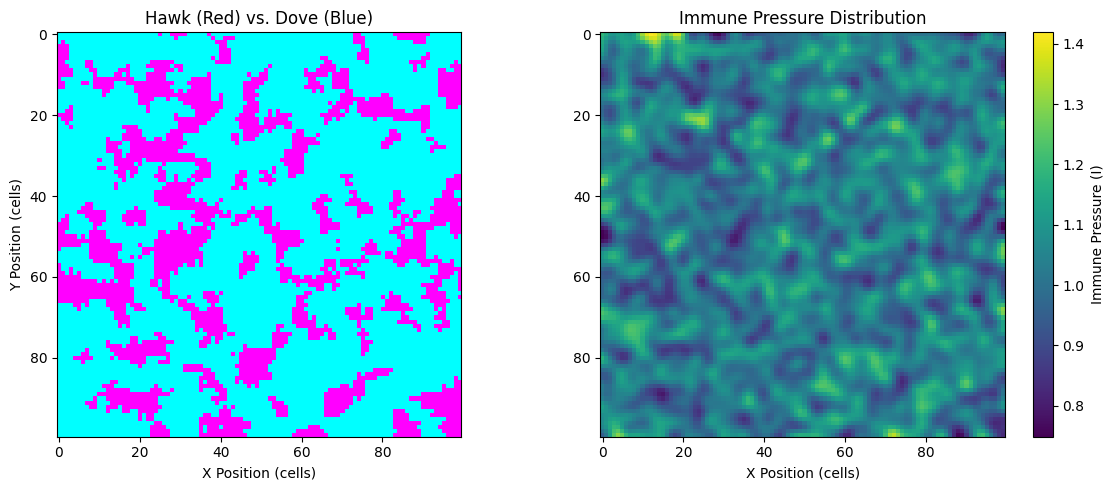

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Generate I_grid and simulate clusters (same as before)
n = 100
b, c = 2.0, 1.0
I_min, I_max = 0.3, 1.7
iterations = 1000
I_grid = np.random.uniform(0.3, 1.7, size=(n, n))
hotspots = np.random.rand(n, n) > 0.95
I_grid[hotspots] += 0.7
I_grid = gaussian_filter(I_grid, sigma=1.5)
I_grid = np.clip(I_grid, 0.3, 1.7)

# Initialize grid
grid = np.random.choice(['H', 'D'], size=(n, n))

# Payoff function (same as before)
def calculate_payoff(grid, i, j, b, c, I):
    neighbors = [(i-1,j), (i+1,j), (i,j-1), (i,j+1)]
    payoff = 0
    for ni, nj in neighbors:
        if 0 <= ni < n and 0 <= nj < n:
            if grid[i,j] == 'H':
                payoff += (b - c - I) if grid[ni,nj] == 'H' else (b - I)
            else:
                payoff += 0 if grid[ni,nj] == 'H' else (b / 2)
    return payoff

# Update rule
def update_grid(grid, b, c, I_grid):
    new_grid = grid.copy()
    for i, j in np.ndindex(grid.shape):
        payoff = calculate_payoff(grid, i, j, b, c, I_grid[i,j])
        neighbors = [(i-1,j), (i+1,j), (i,j-1), (i,j+1)]
        valid_neighbors = [(ni,nj) for ni,nj in neighbors if 0 <= ni < n and 0 <= nj < n]
        if valid_neighbors:
            ni, nj = valid_neighbors[np.random.randint(len(valid_neighbors))]
            neighbor_payoff = calculate_payoff(grid, ni, nj, b, c, I_grid[ni,nj])
            if neighbor_payoff > payoff:
                new_grid[i,j] = grid[ni,nj]
    return new_grid

# Run simulation
for _ in range(iterations):
    grid = update_grid(grid, b, c, I_grid)

# Create figure
plt.figure(figsize=(12, 5))

# Plot 1: Hawk-Dove clusters
plt.subplot(121)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid],
           cmap='cool', interpolation='nearest')
plt.title('Hawk (Red) vs. Dove (Blue)')
plt.xlabel('X Position (cells)')
plt.ylabel('Y Position (cells)')

# Plot 2: Immune pressure heatmap
plt.subplot(122)
heatmap = plt.imshow(I_grid, cmap='viridis', interpolation='nearest')
plt.colorbar(heatmap, label='Immune Pressure (I)')
plt.title('Immune Pressure Distribution')
plt.xlabel('X Position (cells)')

plt.tight_layout()
plt.show()

In [6]:
#count dove clusters
from skimage.measure import label
dove_clusters = label(grid == 'D')
print(f"Number of Dove clusters: {dove_clusters.max()}")

Number of Dove clusters: 10


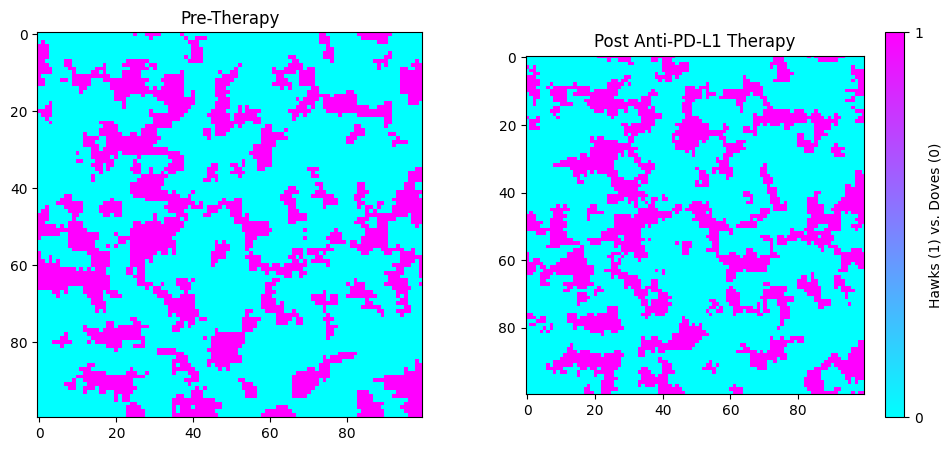

Doves pre-therapy: 7200, post-therapy: 7116


In [8]:
# Initialize post-therapy grid (remove 90% of Doves)
therapy_grid = np.where(np.random.rand(n, n) < 0.1, grid, 'H')  # 10% Doves survive

# Simulate recovery for x iterations
post_therapy_iterations = 1000
for _ in range(post_therapy_iterations):
    therapy_grid = update_grid(therapy_grid, b, c, I_grid)

# Plot therapy response
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in grid], cmap='cool')
plt.title('Pre-Therapy')
plt.subplot(122)
plt.imshow([[1 if cell == 'H' else 0 for cell in row] for row in therapy_grid], cmap='cool')
plt.title('Post Anti-PD-L1 Therapy')
plt.colorbar(label='Hawks (1) vs. Doves (0)', ticks=[0, 1], ax=plt.gca())
plt.show()

# Quantify changes
pre_therapy_doves = np.sum(grid == 'D')
post_therapy_doves = np.sum(therapy_grid == 'D')
print(f"Doves pre-therapy: {pre_therapy_doves}, post-therapy: {post_therapy_doves}")

Correlation (Doves vs. I): r=0.63, p=0.00e+00


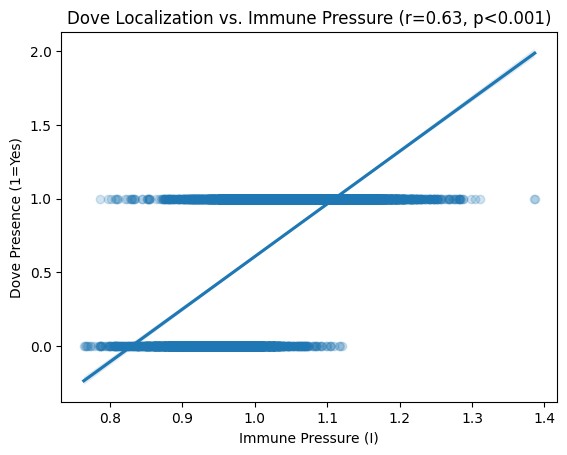

In [19]:
from scipy.stats import pearsonr
import seaborn as sns
sns.regplot(x=I_flat, y=dove_mask, scatter_kws={'alpha':0.1})

# Flatten grids for analysis
dove_mask = (grid == 'D').flatten()
I_flat = I_grid.flatten()

# Calculate correlation
r, p = pearsonr(dove_mask, I_flat)
print(f"Correlation (Doves vs. I): r={r:.2f}, p={p:.2e}")

# Plot
plt.scatter(I_flat, dove_mask, alpha=0.1)
plt.xlabel('Immune Pressure (I)')
plt.ylabel('Dove Presence (1=Yes)')
plt.title(f'Dove Localization vs. Immune Pressure (r={r:.2f})')
plt.xlabel('Immune Pressure (I)')
plt.ylabel('Dove Presence (1=Yes)')
plt.title(f'Dove Localization vs. Immune Pressure (r={r:.2f}, p<0.001)')
plt.show()